# Comparison: Experiment vs Tree Validation

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

# Paths
experiment_path = "experiment_results_summary.csv"
tree_path = "tree_validation_runs.csv"

# Plot defaults
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.grid"] = True

## Load and Filter experiment_results_summary.csv

In [36]:
df_exp = pd.read_csv(experiment_path)
df_exp_5 = df_exp[df_exp["agent_count"] == 5].copy()

print("experiment_results_summary.csv")
print("  total rows:", len(df_exp))
print("  agent_count=5 rows:", len(df_exp_5))

required_cols = ["converge_step", "best_field_final"]
missing_exp = [c for c in required_cols if c not in df_exp_5.columns]
print("  missing required cols:", missing_exp)
print("  columns:", list(df_exp_5.columns))

experiment_results_summary.csv
  total rows: 30014
  agent_count=5 rows: 4289
  missing required cols: []
  columns: ['run_id', 'timestamp', 'agent_count', 'seed', 'field_seed', 'max_steps', 'steps_executed', 'converged', 'converge_step', 'best_field_final', 'mean_field_final', 'best_field_min_over_run', 'improvement_from_start', 'swarm_radius_final', 'avg_speed_final', 'runtime_ms']


## Load tree_validation_runs.csv (no filter)

In [37]:
df_tree = pd.read_csv(tree_path)

print("tree_validation_runs.csv")
print("  total rows:", len(df_tree))
missing_tree = [c for c in required_cols if c not in df_tree.columns]
print("  missing required cols:", missing_tree)
print("  columns:", list(df_tree.columns))

tree_validation_runs.csv
  total rows: 4500
  missing required cols: []
  columns: ['run_id', 'timestamp', 'seed', 'field_seed', 'tree_file', 'agent_count', 'max_steps', 'window', 'hold', 'num_gaussians', 'eps_v', 'eps_f', 'use_speed_check', 'init_pos_range', 'init_vel_range', 'steps_executed', 'converged', 'converge_step', 'best_field_final', 'mean_field_final', 'best_field_min_over_run', 'improvement_from_start', 'swarm_radius_final', 'avg_speed_final', 'runtime_ms', 'run_seconds']


## Plot: Convergence Step vs Final Best

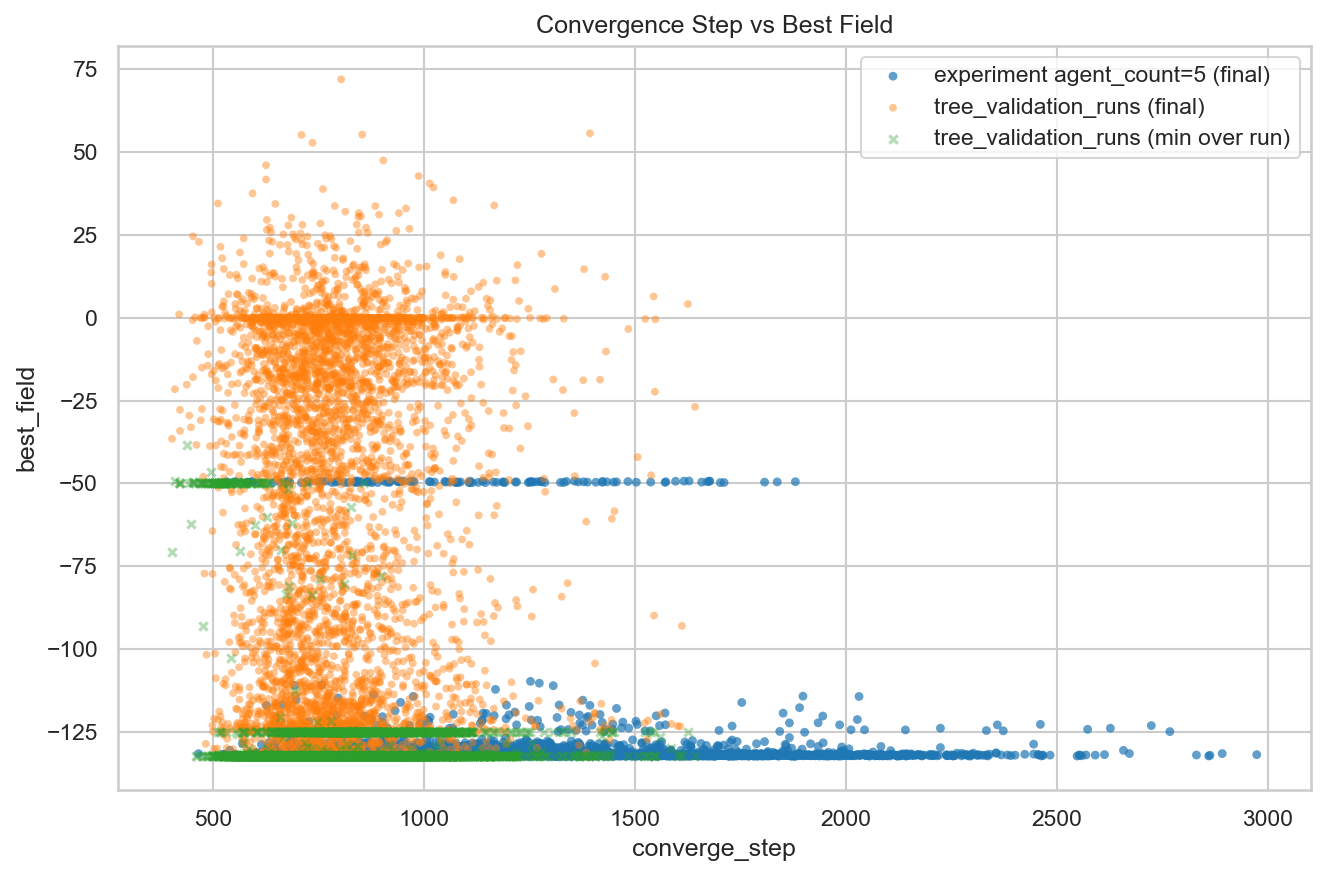

In [38]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_exp_5["converge_step"],
    df_exp_5["best_field_final"],
    s=18,
    alpha=0.7,
    label="experiment agent_count=5 (final)",
    color="tab:blue",
    edgecolors="none",
)

plt.scatter(
    df_tree["converge_step"],
    df_tree["best_field_final"],
    s=14,
    alpha=0.45,
    label="tree_validation_runs (final)",
    color="tab:orange",
    edgecolors="none",
)

if "best_field_min_over_run" in df_tree.columns:
    plt.scatter(
        df_tree["converge_step"],
        df_tree["best_field_min_over_run"],
        s=16,
        alpha=0.35,
        label="tree_validation_runs (min over run)",
        color="tab:green",
        marker="x",
    )

plt.xlabel("converge_step")
plt.ylabel("best_field")
plt.title("Convergence Step vs Best Field")
plt.legend()
plt.tight_layout()
plt.show()

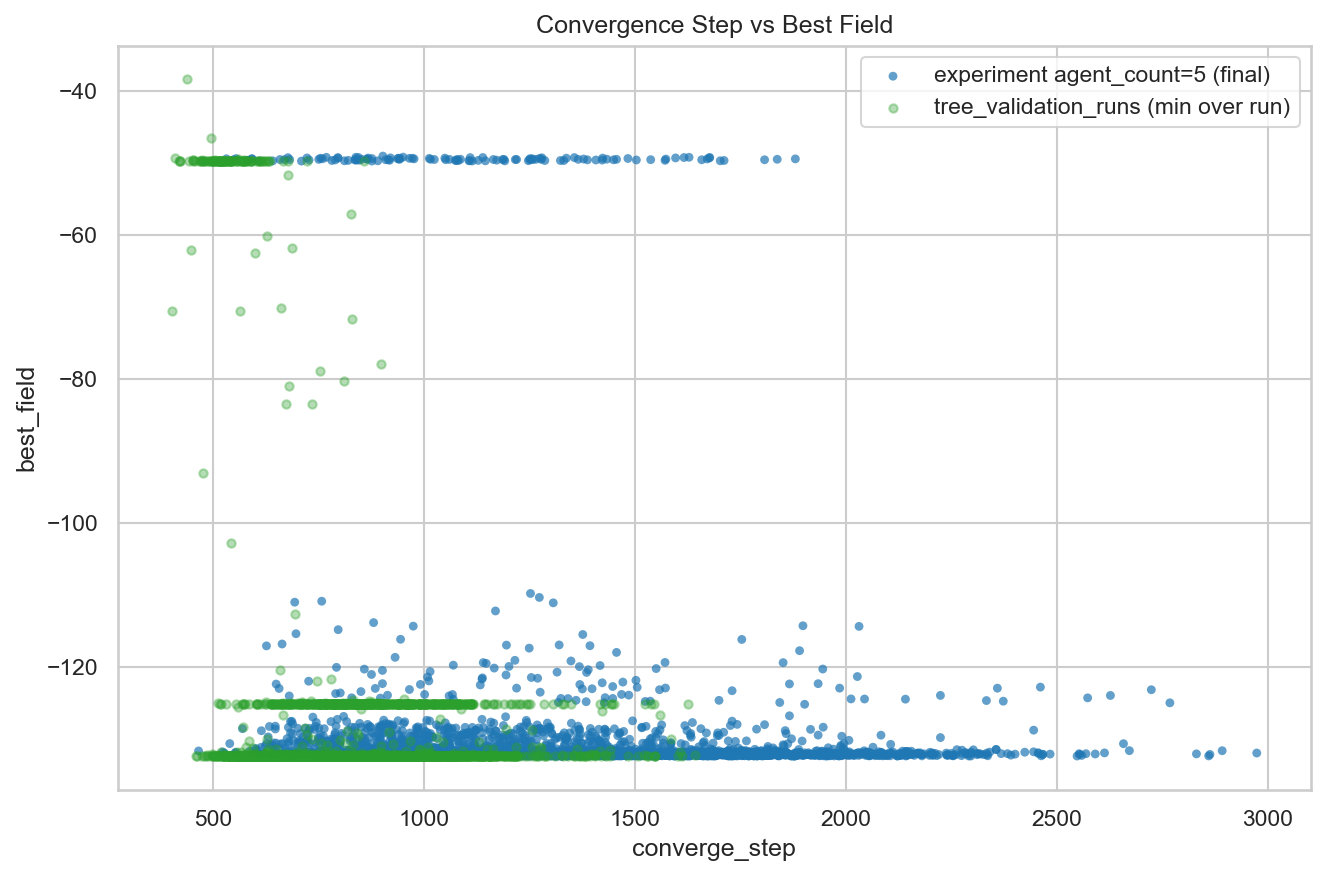

In [39]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_exp_5["converge_step"],
    df_exp_5["best_field_final"],
    s=18,
    alpha=0.7,
    label="experiment agent_count=5 (final)",
    color="tab:blue",
    edgecolors="none",
)


if "best_field_min_over_run" in df_tree.columns:
    plt.scatter(
        df_tree["converge_step"],
        df_tree["best_field_min_over_run"],
        s=16,
        alpha=0.35,
        label="tree_validation_runs (min over run)",
        color="tab:green",
    )

plt.xlabel("converge_step")
plt.ylabel("best_field")
plt.title("Convergence Step vs Best Field")
plt.legend()
plt.tight_layout()
plt.show()

## Plot: Additional Comparison Charts

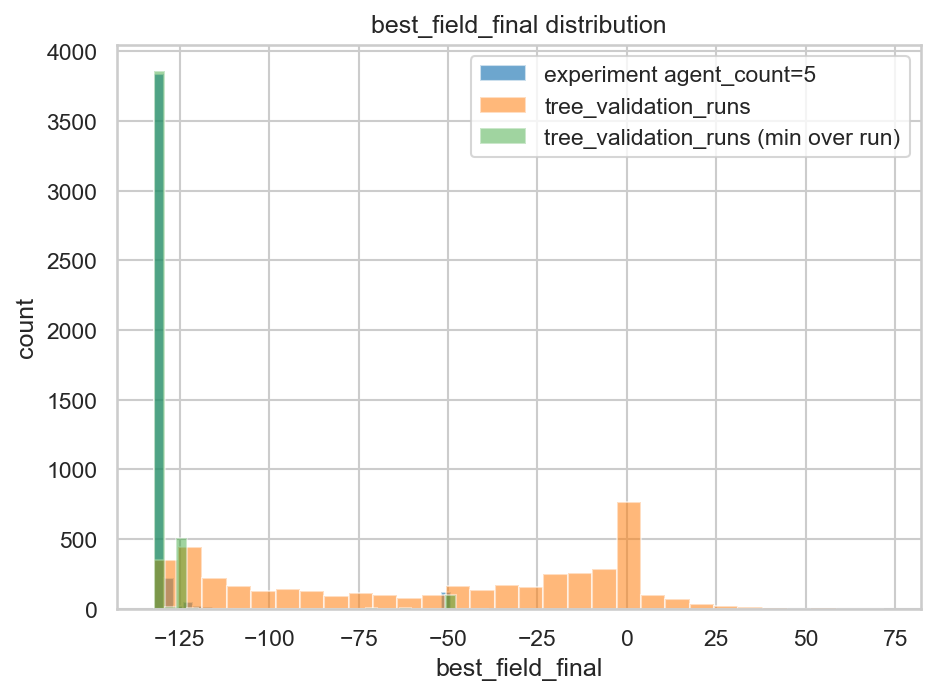

In [40]:

# Distribution of best_field_final
plt.hist(
    df_exp_5["best_field_final"],
    bins=30,
    alpha=0.65,
    label="experiment agent_count=5",
    color="tab:blue",
)
plt.hist(
    df_tree["best_field_final"],
    bins=30,
    alpha=0.55,
    label="tree_validation_runs",
    color="tab:orange",
)
plt.hist(
    df_tree["best_field_min_over_run"],
    bins=30,
    alpha=0.45,
    label="tree_validation_runs (min over run)",
    color="tab:green",
)

plt.title("best_field_final distribution")
plt.xlabel("best_field_final")
plt.ylabel("count")
plt.legend()

plt.tight_layout()
plt.show()

## Zoomed Violin: Over-Run vs Agent=5

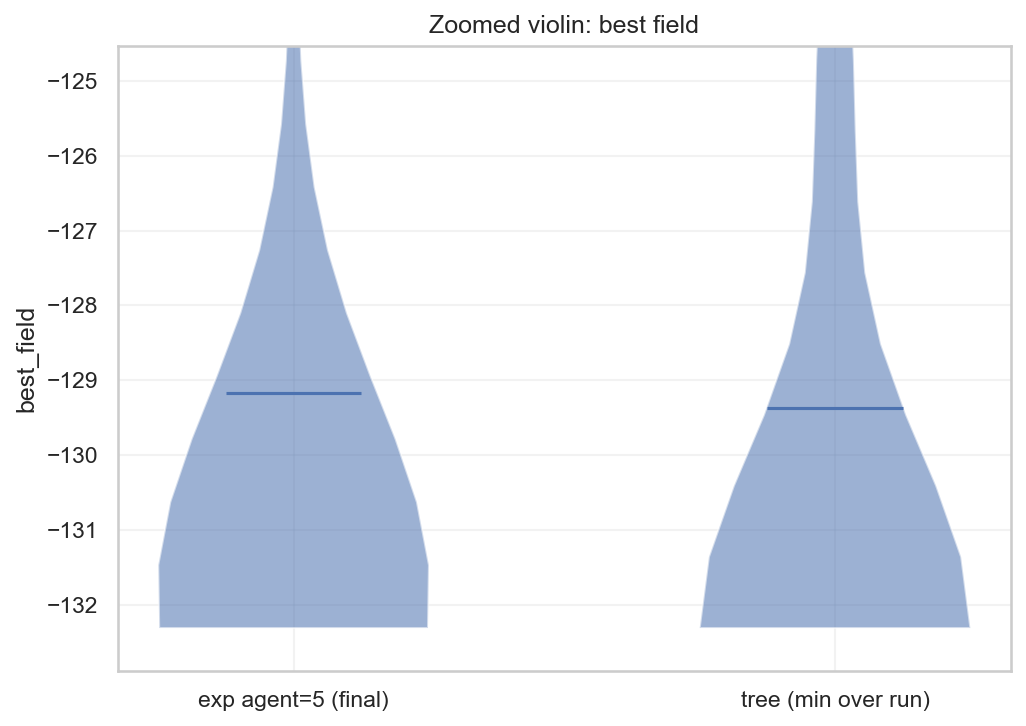

In [41]:
exp_final = df_exp_5["best_field_final"].dropna()
if "best_field_min_over_run" in df_tree.columns:
    tree_min = df_tree["best_field_min_over_run"].dropna()
else:
    tree_min = df_tree["best_field_final"].dropna()

combined = pd.concat([exp_final, tree_min], ignore_index=True)
ymin = combined.quantile(0.05)
ymax = combined.quantile(0.95)
margin = (ymax - ymin) * 0.08

plt.figure(figsize=(7, 5))
parts = plt.violinplot(
    [exp_final.values, tree_min.values],
    showmeans=True,
    showmedians=False,
    showextrema=False,
)
for pc in parts["bodies"]:
    pc.set_alpha(0.55)

plt.xticks([1, 2], ["exp agent=5 (final)", "tree (min over run)"])
plt.title("Zoomed violin: best field")
plt.ylabel("best_field")
plt.ylim(ymin - margin, ymax + margin)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Two-Row Heatmaps (Reach Rate + Count)

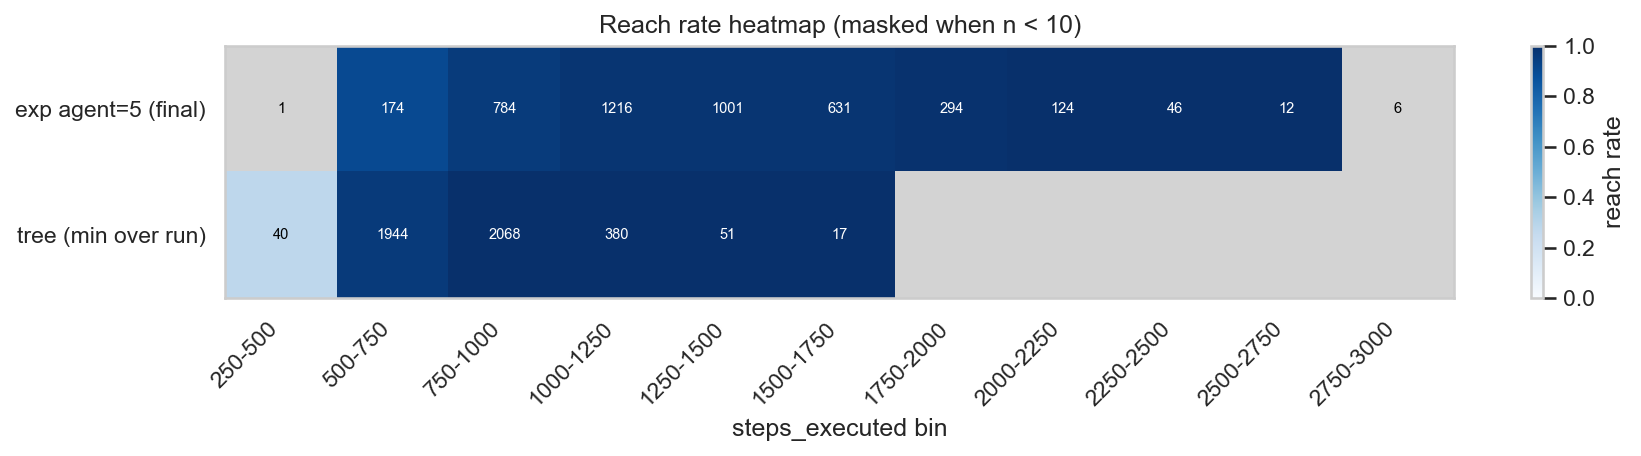

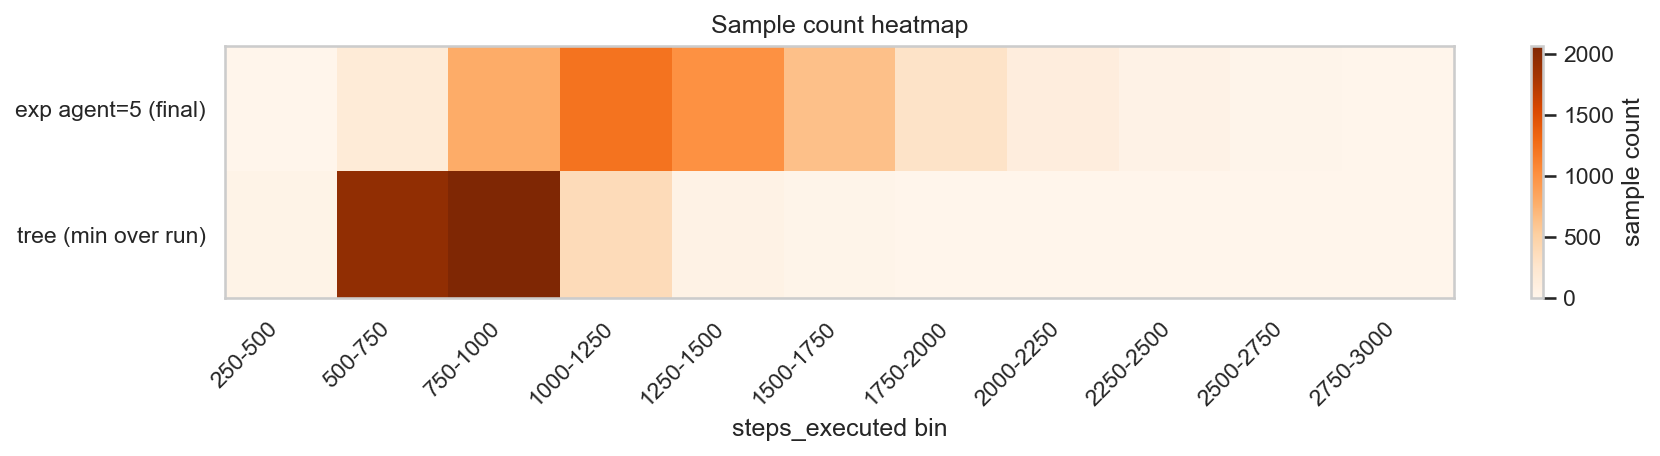

cut_y (from combined gap): -97.930700


In [42]:
# Define a shared cut based on the largest gap (same idea as main.ipynb)
combined_vals = np.sort(combined.to_numpy())
gaps = np.diff(combined_vals)
cut_idx = int(np.argmax(gaps)) if len(gaps) > 0 else 0
cut_y = float((combined_vals[cut_idx] + combined_vals[min(cut_idx + 1, len(combined_vals) - 1)]) / 2)

exp_heat = pd.DataFrame({
    "dataset": "exp agent=5 (final)",
    "steps_executed": df_exp_5["steps_executed"],
    "best_field": df_exp_5["best_field_final"],
})

tree_heat = pd.DataFrame({
    "dataset": "tree (min over run)",
    "steps_executed": df_tree["steps_executed"],
    "best_field": tree_min,
})

heat_df = pd.concat([exp_heat, tree_heat], ignore_index=True)
heat_df["reached"] = heat_df["best_field"] <= cut_y

# Step bins similar to main.ipynb, but dynamic to data range
bin_size = 250
step_min = int(np.floor(heat_df["steps_executed"].min() / bin_size) * bin_size)
step_max = int(np.ceil(heat_df["steps_executed"].max() / bin_size) * bin_size)
step_bins = np.arange(step_min, step_max + bin_size, bin_size)
heat_df["step_bin"] = pd.cut(heat_df["steps_executed"], bins=step_bins, include_lowest=True, right=False)

rate_tbl = heat_df.pivot_table(
    index="dataset",
    columns="step_bin",
    values="reached",
    aggfunc="mean",
    observed=False,
)
count_tbl = heat_df.pivot_table(
    index="dataset",
    columns="step_bin",
    values="reached",
    aggfunc="size",
    fill_value=0,
    observed=False,
)

# Align columns and mask low counts
count_for_rate = count_tbl.reindex(columns=rate_tbl.columns, fill_value=0)
min_count = 10
rate_masked = rate_tbl.where(count_for_rate >= min_count)

# Heatmap: reach rate
plt.figure(figsize=(12, 3.2))
cmap_rate = plt.cm.Blues.copy()
cmap_rate.set_bad(color="lightgray")
im = plt.imshow(rate_masked.to_numpy(dtype=float), aspect="auto", cmap=cmap_rate, vmin=0, vmax=1)
plt.colorbar(im, label="reach rate")
plt.yticks(range(len(rate_masked.index)), rate_masked.index)
col_labels = [f"{int(iv.left)}-{int(iv.right)}" for iv in rate_masked.columns]
plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha="right")
plt.xlabel("steps_executed bin")
plt.title(f"Reach rate heatmap (masked when n < {min_count})")
plt.grid(False)

counts_np = count_for_rate.to_numpy()
rate_np = rate_masked.to_numpy(dtype=float)
for i in range(rate_np.shape[0]):
    for j in range(rate_np.shape[1]):
        n_ij = int(counts_np[i, j])
        if n_ij > 0:
            r_ij = rate_np[i, j]
            txt_color = "white" if (not np.isnan(r_ij) and r_ij >= 0.55) else "black"
            plt.text(j, i, str(n_ij), ha="center", va="center", fontsize=7, color=txt_color)

plt.tight_layout()
plt.show()

# Heatmap: sample counts
plt.figure(figsize=(12, 3.2))
im2 = plt.imshow(count_tbl.to_numpy(dtype=float), aspect="auto", cmap="Oranges")
plt.colorbar(im2, label="sample count")
plt.yticks(range(len(count_tbl.index)), count_tbl.index)
col_labels = [f"{int(iv.left)}-{int(iv.right)}" for iv in count_tbl.columns]
plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha="right")
plt.xlabel("steps_executed bin")
plt.title("Sample count heatmap")
plt.grid(False)
plt.tight_layout()
plt.show()

print(f"cut_y (from combined gap): {cut_y:.6f}")

## Quick Numeric Comparison

In [43]:
common_metrics = [
    "best_field_final",
    "mean_field_final",
    "best_field_min_over_run",
    "improvement_from_start",
    "converge_step",
    "steps_executed",
    "swarm_radius_final",
    "avg_speed_final",
    "runtime_ms",
]
metrics = [m for m in common_metrics if m in df_exp_5.columns and m in df_tree.columns]

if not metrics:
    raise ValueError("No shared numeric metrics found between datasets.")


def make_summary(df, label):
    rows = []
    for m in metrics:
        series = df[m].dropna()
        rows.append({
            "metric": m,
            f"{label}_mean": series.mean(),
            f"{label}_median": series.median(),
            f"{label}_p05": series.quantile(0.05),
            f"{label}_p95": series.quantile(0.95),
        })
    return pd.DataFrame(rows).set_index("metric")


summary = make_summary(df_exp_5, "exp").join(make_summary(df_tree, "tree"))
summary["delta_mean_tree_minus_exp"] = summary["tree_mean"] - summary["exp_mean"]
summary["delta_median_tree_minus_exp"] = summary["tree_median"] - summary["exp_median"]

core_metrics = [
    "best_field_final",
    "best_field_min_over_run",
    "improvement_from_start",
    "converge_step",
    "steps_executed",
]
core_metrics = [m for m in core_metrics if m in summary.index]

print("Rows: exp agent_count=5 =", len(df_exp_5), ", tree_validation =", len(df_tree))
print("Core metrics summary (mean/median/5-95):")
print(summary.loc[core_metrics].round(4).to_string())

if "converged" in df_exp_5.columns and "converged" in df_tree.columns:
    exp_conv = df_exp_5["converged"].mean()
    tree_conv = df_tree["converged"].mean()
    print(f"Converged rate: exp={exp_conv:.3f}, tree={tree_conv:.3f}")

if "best_field_final" in df_exp_5.columns and "best_field_final" in df_tree.columns:
    exp_median = df_exp_5["best_field_final"].median()
    tree_median = df_tree["best_field_final"].median()
    tree_better_than_exp_median = (df_tree["best_field_final"] <= exp_median).mean()
    exp_better_than_tree_median = (df_exp_5["best_field_final"] <= tree_median).mean()
    print(f"Median best_field_final: exp={exp_median:.4f}, tree={tree_median:.4f}")
    print(f"Tree <= exp median: {tree_better_than_exp_median:.3f}")
    print(f"Exp <= tree median: {exp_better_than_tree_median:.3f}")

Rows: exp agent_count=5 = 4289 , tree_validation = 4500
Core metrics summary (mean/median/5-95):
                          exp_mean  exp_median   exp_p05    exp_p95  tree_mean  tree_median  tree_p05   tree_p95  delta_mean_tree_minus_exp  delta_median_tree_minus_exp
metric                                                                                                                                                                  
best_field_final         -129.1617   -131.9940 -132.2730  -124.3132   -54.1418     -43.0730 -128.5126     5.3640                    75.0199                      88.9210
best_field_min_over_run  -129.8239   -132.3030 -132.3040  -125.1310  -129.3645    -132.2970 -132.3040  -125.1100                     0.4594                       0.0060
improvement_from_start     93.1290     99.8532   43.4952   124.5512   108.2313     109.5385   83.5613   132.9478                    15.1023                       9.6853
converge_step            1291.7116   1246.0000  772.8000  

## GA Log: Mean Score per Generation

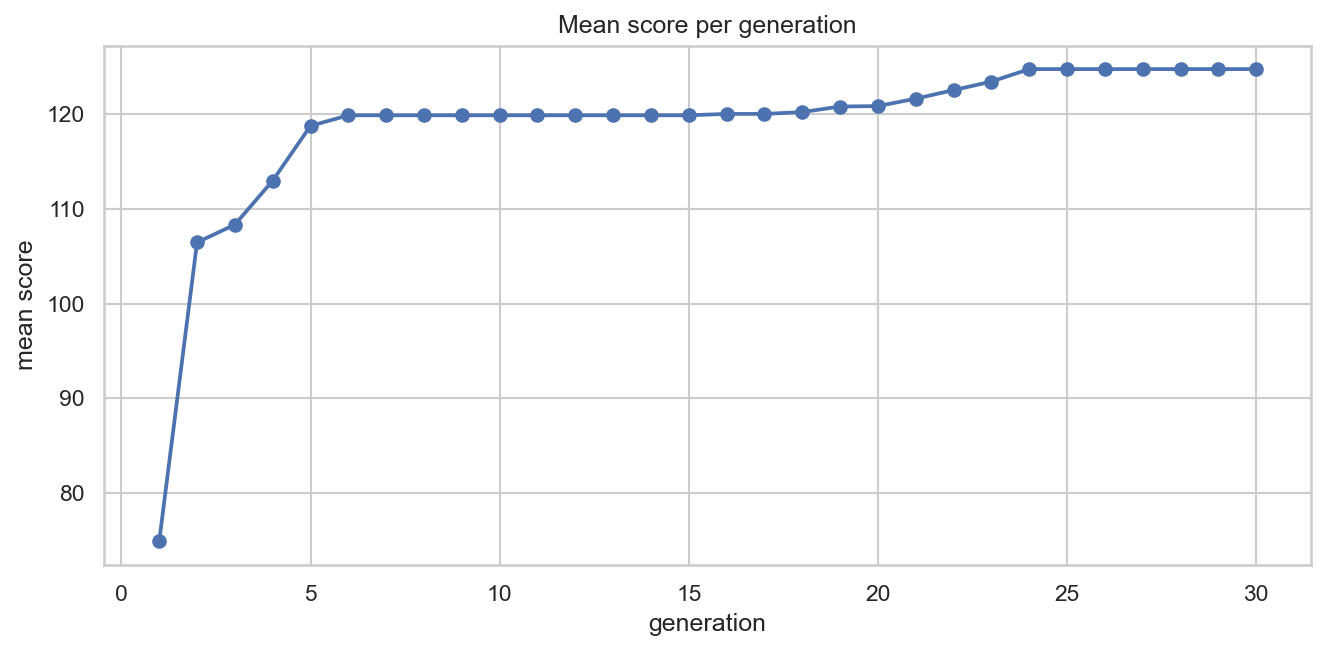

rows used: 152 generations: 1 -> 30


In [44]:
ga_path = "tree_ga_log.csv"
df_ga = pd.read_csv(ga_path)

if "generation" not in df_ga.columns:
    raise ValueError("generation column not found in tree_ga_log.csv")

# Prefer candidate rows for averaging; fall back to generation rows if needed
if "row_type" in df_ga.columns and (df_ga["row_type"] == "candidate").any():
    base = df_ga[df_ga["row_type"] == "candidate"].copy()
    score_col = "score"
elif "score" in df_ga.columns:
    base = df_ga.copy()
    score_col = "score"
elif "score_mean" in df_ga.columns:
    base = df_ga[df_ga["row_type"] == "generation"].copy() if "row_type" in df_ga.columns else df_ga.copy()
    score_col = "score_mean"
else:
    raise ValueError("No score or score_mean column found in tree_ga_log.csv")

mean_by_gen = base.groupby("generation")[score_col].mean().sort_index()

plt.figure(figsize=(9, 4.5))
plt.plot(mean_by_gen.index, mean_by_gen.values, marker="o", linewidth=1.8)
plt.xlabel("generation")
plt.ylabel(f"mean {score_col}")
plt.title("Mean score per generation")
plt.tight_layout()
plt.show()

print("rows used:", len(base), "generations:", mean_by_gen.index.min(), "->", mean_by_gen.index.max())